In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development.

In [46]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("https://raw.githubusercontent.com/ashishsantikari/lab-natural-language-processing/refs/heads/main/data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development.
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


### Let's divide the training and test set into two partitions

In [53]:
# Your code
data_train, data_val = data[:800].copy(), data[800:].copy()
display(data_train.head())
display(data_val.head())

,text,label
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1
1,Will do.,0
2,Nora--Cheryl has emailed dozens of memos about...,0
3,Dear Sir=2FMadam=2C I know that this proposal ...,1
4,fyi,0


,text,label
800,Lona---Could we be ready to do on or before 12...,0
801,"Dear Sir/madam,This letter might surprise you ...",1
802,Foreign Exchange DepartmentFirst National Bank...,1
803,<html><head><style>P{margin:0px;padding:0px}body,1
804,yes,0


## Data Preprocessing

In [54]:
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [55]:
# Your code
import re

def clean_html(text):
    # 1. Remove inline JavaScript/CSS
    text = re.sub(r'<(script|style)[^>]*>.*?</(script|style)>', '', text, flags=re.DOTALL | re.IGNORECASE)

    # 2. Remove HTML comments (before tags, since comments can contain '>')
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

    # 3. Remove remaining HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    return text

data_train.loc[:, 'preprocessed_text'] = data_train['text'].apply(clean_html)
data_val.loc[:, 'preprocessed_text'] = data_val['text'].apply(clean_html)

display(data_train.head())


,text,label,preprocessed_text
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL..."
1,Will do.,0,Will do.
2,Nora--Cheryl has emailed dozens of memos about...,0,Nora--Cheryl has emailed dozens of memos about...
3,Dear Sir=2FMadam=2C I know that this proposal ...,1,Dear Sir=2FMadam=2C I know that this proposal ...
4,fyi,0,fyi


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters

- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [56]:
# Your code
def clean_text(text):
    # 1. Remove special characters
    text = re.sub(r'\W', ' ', text)

    # 2. Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # 3. Remove single characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)

    # 4. Remove single characters from the start
    text = re.sub(r'^[a-zA-Z]\s+', ' ', text)

    # 5. Substitute multiple spaces with single space
    text = re.sub(r'\s+', ' ', text, flags=re.I)

    # 6. Remove prefixed 'b'
    text = re.sub(r'^b\s+', '', text)

    # 7. Convert to lowercase
    text = text.lower()

    return text

data_train.loc[:, 'preprocessed_text'] = data_train['preprocessed_text'].apply(clean_text)
data_val.loc[:, 'preprocessed_text'] = data_val['preprocessed_text'].apply(clean_text)

data_train.head()

,text,label,preprocessed_text
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1,dear sir strictly private business proposal am...
1,Will do.,0,will do
2,Nora--Cheryl has emailed dozens of memos about...,0,nora cheryl has emailed dozens of memos about ...
3,Dear Sir=2FMadam=2C I know that this proposal ...,1,dear sir fmadam i know that this proposal migh...
4,fyi,0,fyi


## Now let's work on removing stopwords
Remove the stopwords.

In [57]:
# Your code
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

data_train.loc[:, 'preprocessed_text'] = data_train['preprocessed_text'].apply(remove_stopwords)
data_val.loc[:, 'preprocessed_text'] = data_val['preprocessed_text'].apply(remove_stopwords)

data_train.head()


,text,label,preprocessed_text
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1,dear sir strictly private business proposal mi...
1,Will do.,0,
2,Nora--Cheryl has emailed dozens of memos about...,0,nora cheryl emailed dozens memos haiti weekend...
3,Dear Sir=2FMadam=2C I know that this proposal ...,1,dear sir fmadam know proposal might surprise e...
4,fyi,0,fyi


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [58]:
# Your code
def lemmatize_text(text):
    words = text.split()
    lemmatized = [snowball.stem(
        word) for word in words]
    return ' '.join(lemmatized)

data_train.loc[:, 'preprocessed_text'] = data_train['preprocessed_text'].apply(lemmatize_text)
display(data_train.head())

,text,label,preprocessed_text
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1,dear sir strict privat busi propos mike chukwu...
1,Will do.,0,
2,Nora--Cheryl has emailed dozens of memos about...,0,nora cheryl email dozen memo haiti weekend ple...
3,Dear Sir=2FMadam=2C I know that this proposal ...,1,dear sir fmadam know propos might surpris emer...
4,fyi,0,fyi


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

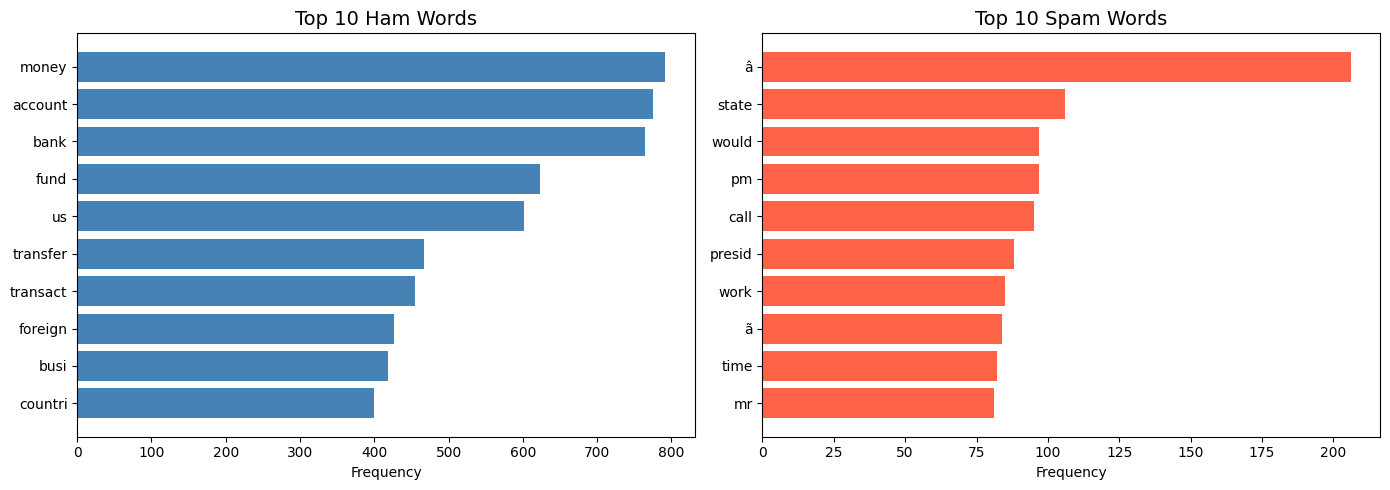

In [59]:
# Your code
from collections import Counter
import matplotlib.pyplot as plt

def get_top_words(df, label, n=10):
    texts = df[df['label'] == label]['preprocessed_text']
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

ham_top = get_top_words(data_train, 1)
spam_top = get_top_words(data_train, 0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top_words, title, color in zip(
    axes,
    [ham_top, spam_top],
    ['Top 10 Ham Words', 'Top 10 Spam Words'],
    ['steelblue', 'tomato']
):
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## Extra features

In [60]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x))

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x))

data_train.head()

,text,label,preprocessed_text,money_mark,suspicious_words,text_len
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1,dear sir strict privat busi propos mike chukwu...,1,1,1301
1,Will do.,0,,0,0,0
2,Nora--Cheryl has emailed dozens of memos about...,0,nora cheryl email dozen memo haiti weekend ple...,0,0,105
3,Dear Sir=2FMadam=2C I know that this proposal ...,1,dear sir fmadam know propos might surpris emer...,1,1,1165
4,fyi,0,fyi,0,0,3


## How would work the Bag of Words with Count Vectorizer concept?

In [61]:
# Your code
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data_train['preprocessed_text'])


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [63]:
# Your code
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(data_train['preprocessed_text'])
print(X_train.shape)


(800, 19240)


## And the Train a Classifier?

In [65]:
# Your code
from sklearn.naive_bayes import MultinomialNB

# 1. Train
classifier = MultinomialNB()
classifier.fit(X_train['preprocessed_text'], X_train['labels'])

# 2. Predict
y_pred = classifier.predict(X_val)

# 3. Evaluate
print(classification_report(y_val, y_pred))

# 4. Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


IndexError: Index dimension must be 1 or 2

### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [ ]:
# Your code